**Prophet**

Primero entrenaremos al modelo con todo el dataframe limpio utilizando la columna cluster como tensor.
A tal efecto, es preciso realizar One-Hote encoding de la columna cluster

En caso de que la tendencia predicha se aleje de la tendencia observada, se procederá a modelar cada cluster por separado.

En caso de que al tendencia predicha se aleja de la tendencia observada en un cluster, se procederá a la hiperparametrización del modelo para ese cluster.

In [1]:
import pandas as pd
from prophet import Prophet
from prophet.diagnostics import cross_validation
from prophet.diagnostics import performance_metrics
from prophet.plot import plot_cross_validation_metric
import matplotlib.pyplot as plt
import plotly.graph_objects as go

In [5]:
#Importar
df = pd.read_pickle(r"C:\Users\User\OneDrive - Universidade de Santiago de Compostela\Documentos\Data Science\Data Science & IA Bootcamp 2024\PFB\Sprint_II\notebooks\Final\temperaturas_limpias_10_años_29_6.pkl")

#Definir
df_I = df[['fecha', 'tmed']].rename(columns={"fecha" : "ds", "tmed" : "y"})

In [7]:
#Entrenar
m = Prophet()
m.fit(df_I)

15:19:26 - cmdstanpy - INFO - Chain [1] start processing
15:44:11 - cmdstanpy - INFO - Chain [1] done processing


In [9]:
#Predecir diferentes granuladidades
periods = [1, 7, 30, 90, 183, 365]
forecasts = {}

for i in periods:
    future = m.make_future_dataframe(periods=i)
    forecast = m.predict(future)
    forecasts[i] = forecast #[['ds', 'yhat', 'yhat_lower', 'yhat_upper']] esto solo para chequar

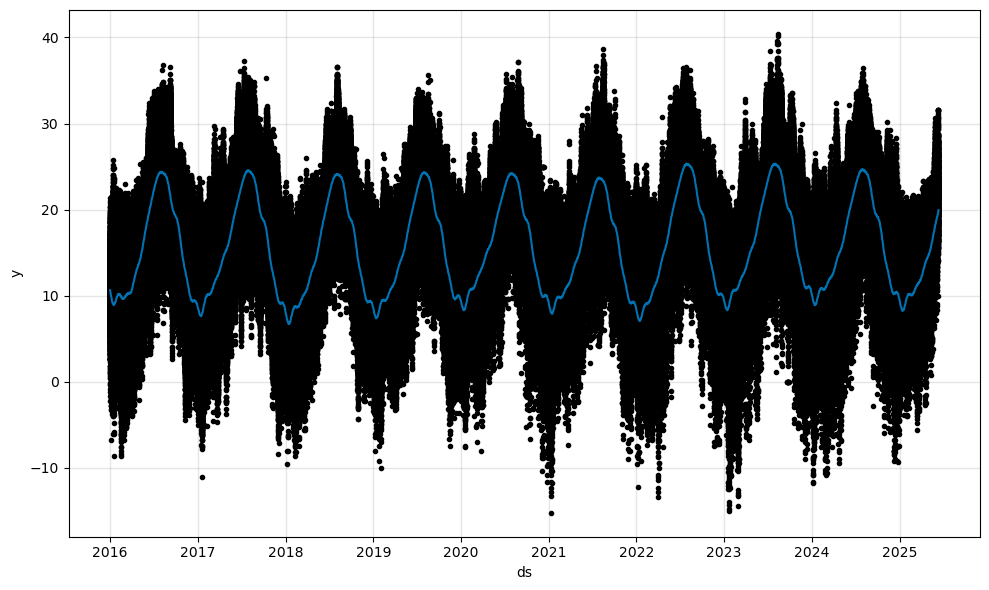

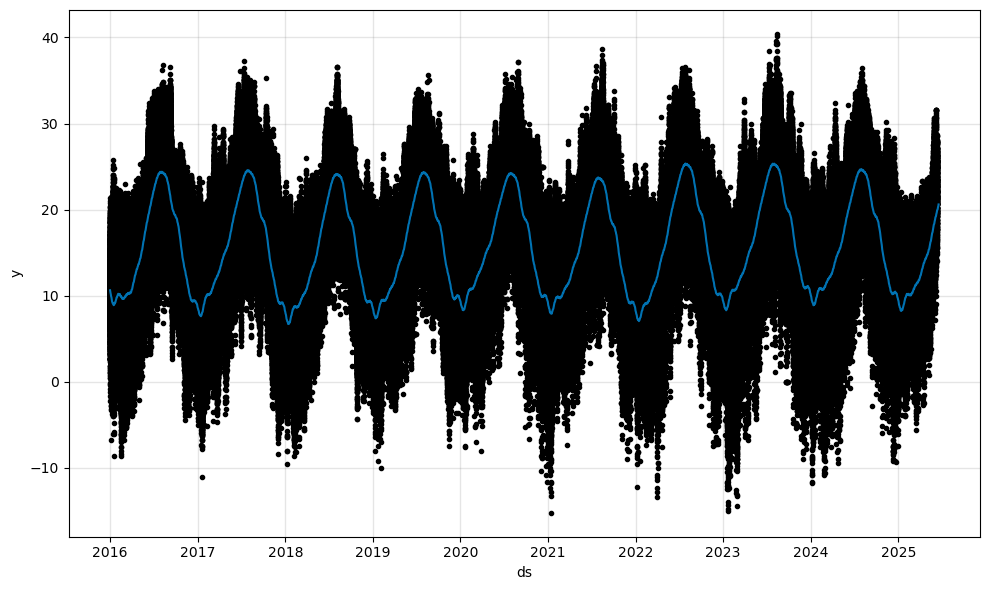

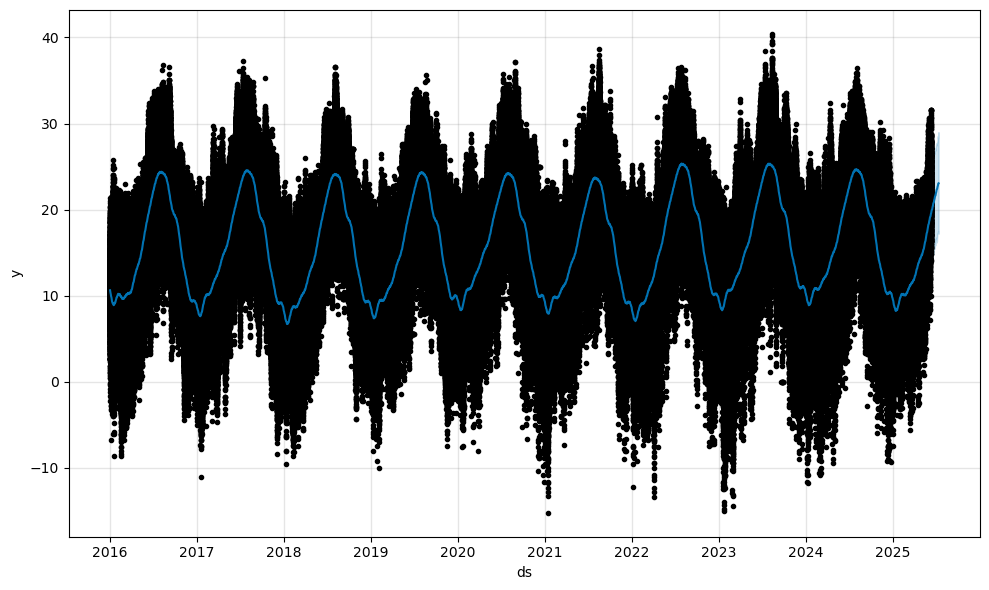

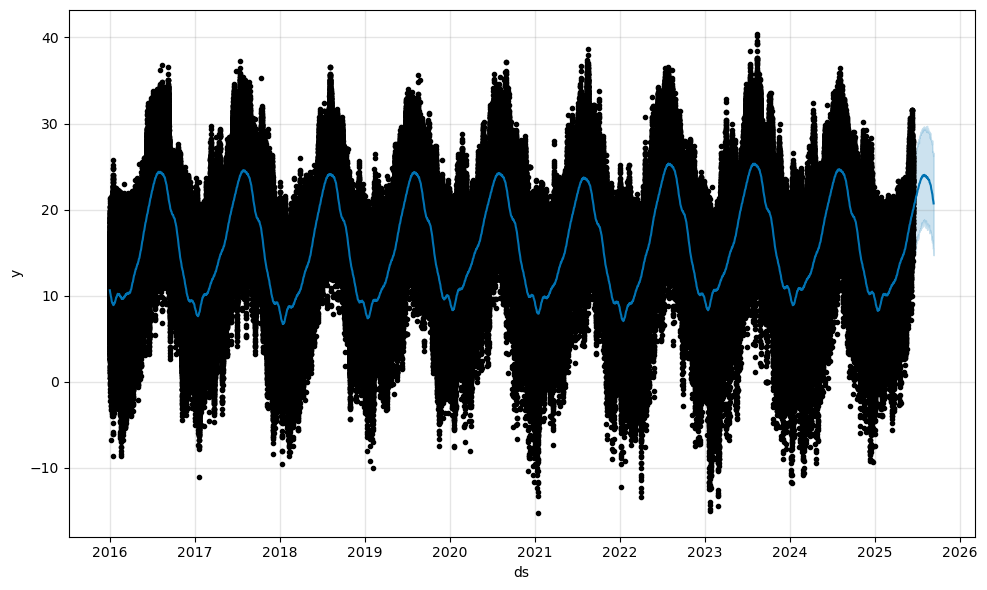

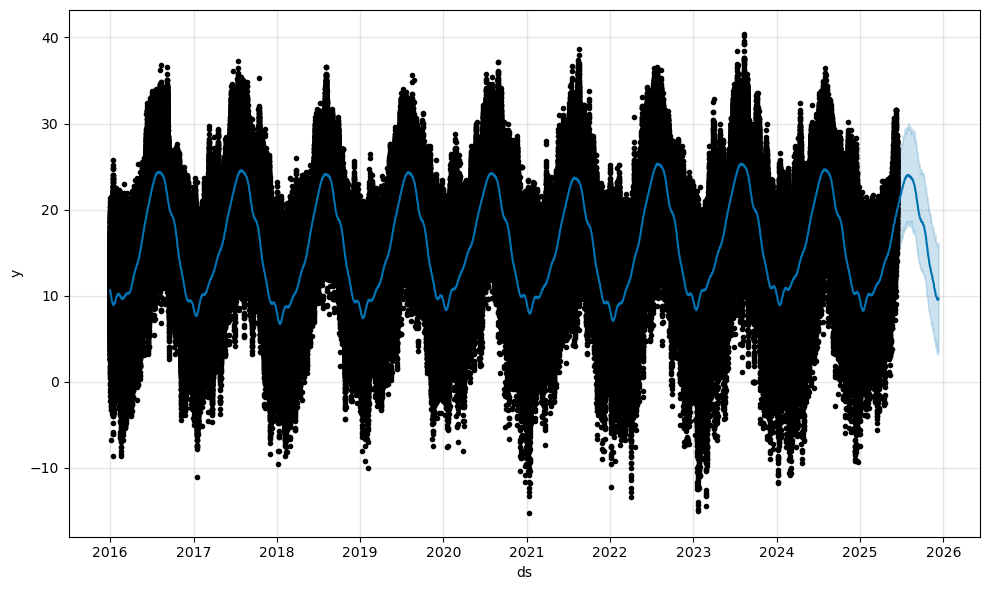

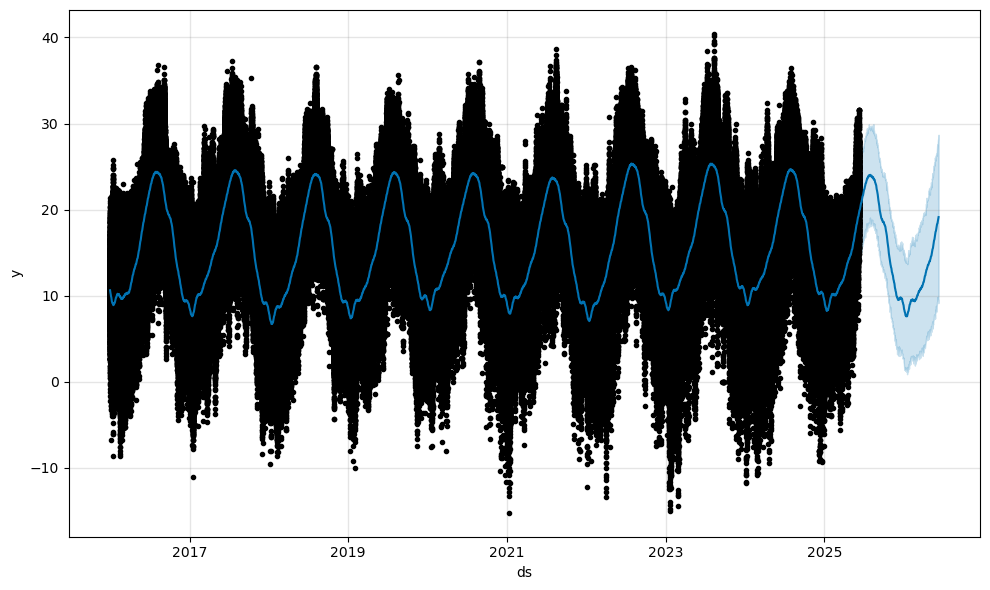

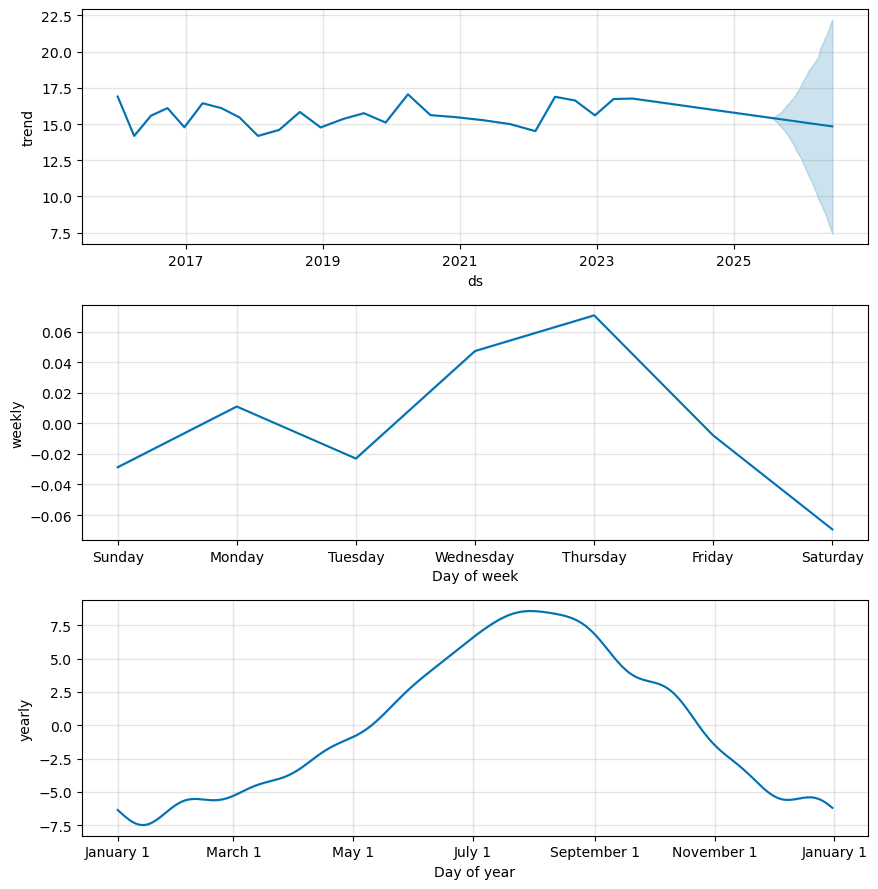

In [11]:
#Visualizar
forecast_day = forecasts[1]
forecast_week = forecasts[7]
forecast_month = forecasts[30]
forecast_trimestre = forecasts[90]
forecast_semestre = forecasts[183]
forecast_year = forecasts[365]

fig1 = m.plot(forecast_day)
fig2 = m.plot(forecast_week)
fig3 = m.plot(forecast_month)
fig4 = m.plot(forecast_trimestre)
fig5 = m.plot(forecast_semestre)
fig6 = m.plot(forecast_year)

fig7 = m.plot_components(forecast_year)

In [15]:
#Validation: Entrenar con dos años, validar cada 1 año y predecir hasta 6 meses. 
#Para 10 años son 1080 pronosticos (son 6 folds * 180 pronosticos)
df_cv = cross_validation(m, initial='730 days', period='360 days', horizon = '180 days')

  0%|          | 0/8 [00:00<?, ?it/s]

15:58:43 - cmdstanpy - INFO - Chain [1] start processing
16:04:53 - cmdstanpy - INFO - Chain [1] done processing
16:06:28 - cmdstanpy - INFO - Chain [1] start processing
16:17:19 - cmdstanpy - INFO - Chain [1] done processing
16:19:15 - cmdstanpy - INFO - Chain [1] start processing
16:30:11 - cmdstanpy - INFO - Chain [1] done processing
16:32:14 - cmdstanpy - INFO - Chain [1] start processing
16:48:05 - cmdstanpy - INFO - Chain [1] done processing
16:50:32 - cmdstanpy - INFO - Chain [1] start processing
17:05:45 - cmdstanpy - INFO - Chain [1] done processing
17:08:38 - cmdstanpy - INFO - Chain [1] start processing
17:25:11 - cmdstanpy - INFO - Chain [1] done processing
17:28:28 - cmdstanpy - INFO - Chain [1] start processing
17:50:56 - cmdstanpy - INFO - Chain [1] done processing
17:53:36 - cmdstanpy - INFO - Chain [1] start processing
18:06:56 - cmdstanpy - INFO - Chain [1] done processing


In [17]:
#Métricas validación cruzada
df_p = performance_metrics(df_cv)
print(df_p[['horizon', 'rmse', 'mae']].mean())  # RMSE y MAE promedios para un horizonte
print(df_p.groupby(pd.to_timedelta(df_p['horizon']).dt.days // 30)['rmse'].mean()) #Agrupar RMSE por mes para ver la evolucion con el correr del horizonte

horizon    98 days 12:00:00
rmse               6.722856
mae                5.041752
dtype: object
horizon
0    4.895313
1    5.066573
2    5.590444
3    6.989903
4    7.720493
5    8.951044
6    9.355549
Name: rmse, dtype: float64


C:\Users\User\AppData\Local\r-miniconda\envs\PFB\lib\site-packages\prophet\plot.py:547: FutureWarning: Series.view is deprecated and will be removed in a future version. Use ``astype`` as an alternative to change the dtype.
  x_plt = df_none['horizon'].astype('timedelta64[ns]').view(np.int64) / float(dt_conversions[i])
C:\Users\User\AppData\Local\r-miniconda\envs\PFB\lib\site-packages\prophet\plot.py:548: FutureWarning: Series.view is deprecated and will be removed in a future version. Use ``astype`` as an alternative to change the dtype.
  x_plt_h = df_h['horizon'].astype('timedelta64[ns]').view(np.int64) / float(dt_conversions[i])


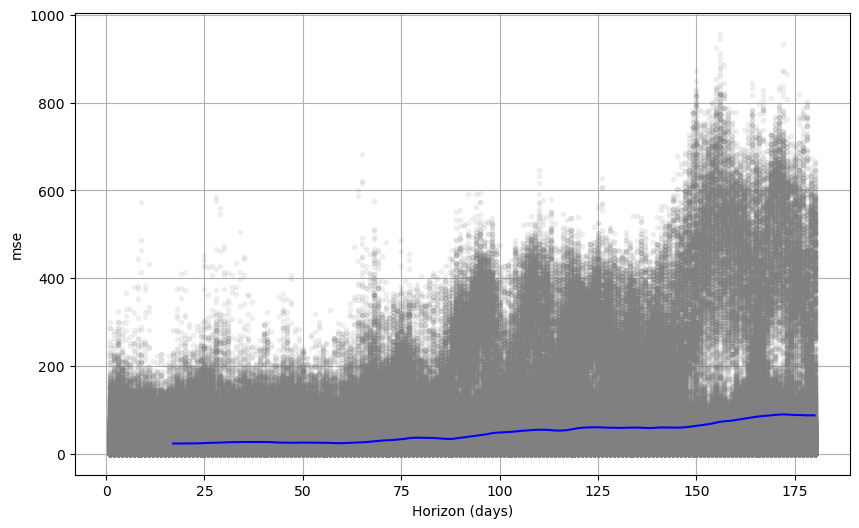

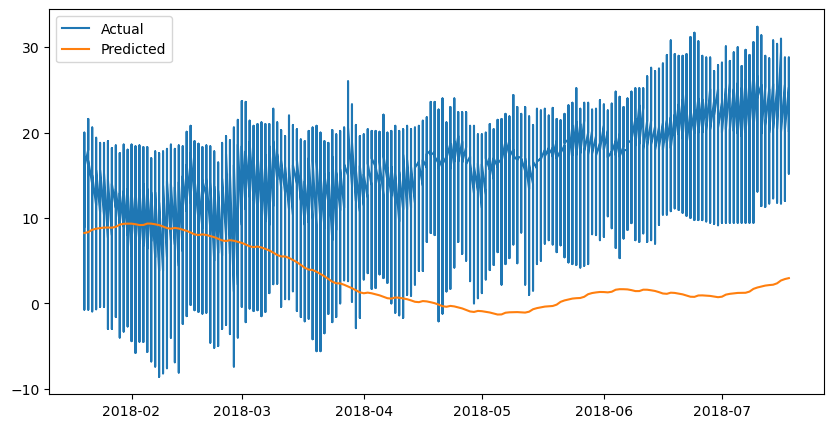

In [19]:
#Grafico variacion MSE en función del horizonte para identificar si el error aumenta con el tiempo
plot_cross_validation_metric(df_cv, metric='mse')

#Gráfico observado vs predicho para un fold
plt.figure(figsize=(10, 5))
fold = df_cv[df_cv['cutoff'] == df_cv['cutoff'].iloc[0]]
plt.plot(fold['ds'], fold['y'], label='Actual')
plt.plot(fold['ds'], fold['yhat'], label='Predicted')
plt.legend()
plt.show()

**La diferencia entre Predicho y Actual es inaceptable. Se tiene que entrean el modelo en cada cluster por separado.**

In [ ]:
#Importar
df = pd.read_pickle(r"C:\Users\User\OneDrive - Universidade de Santiago de Compostela\Documentos\Data Science\Data Science & IA Bootcamp 2024\PFB\Sprint_II\notebooks\Final\temperaturas_limpias_10_años_29_6.pkl")

#Definir
df_I = df[['fecha', 'tmed']].rename(columns={"fecha" : "ds", "tmed" : "y"})

#Entrenar
m = Prophet()
m.fit(df_I)

#Predecir diferentes granuladidades
periods = [1, 7, 30, 90, 183, 365]
forecasts = {}

for i in periods:
    future = m.make_future_dataframe(periods=i)
    forecast = m.predict(future)
    forecasts[i] = forecast #[['ds', 'yhat', 'yhat_lower', 'yhat_upper']] esto solo para chequar

#Visualizar
forecast_day = forecasts[1]
forecast_week = forecasts[7]
forecast_month = forecasts[30]
forecast_trimestre = forecasts[90]
forecast_semestre = forecasts[183]
forecast_year = forecasts[365]

fig1 = m.plot(forecast_day)
fig2 = m.plot(forecast_week)
fig3 = m.plot(forecast_month)
fig4 = m.plot(forecast_trimestre)
fig5 = m.plot(forecast_semestre)
fig6 = m.plot(forecast_year)

fig7 = m.plot_components(forecast_year)

#Validation: Entrenar con dos años, validar cada 1 año y predecir hasta 6 meses. 
#Para 10 años son 1080 pronosticos (son 6 folds * 180 pronosticos)
df_cv = cross_validation(m, initial='730 days', period='360 days', horizon = '180 days')

#Métricas validación cruzada
df_p = performance_metrics(df_cv)
print(df_p[['horizon', 'rmse', 'mae']].mean())  # RMSE y MAE promedios para un horizonte
print(df_p.groupby(pd.to_timedelta(df_p['horizon']).dt.days // 30)['rmse'].mean()) #Agrupar RMSE por mes para ver la evolucion con el correr del horizonte

#Grafico variacion MSE en función del horizonte para identificar si el error aumenta con el tiempo
plot_cross_validation_metric(df_cv, metric='mse')

#Gráfico observado vs predicho para un fold
plt.figure(figsize=(10, 5))
fold = df_cv[df_cv['cutoff'] == df_cv['cutoff'].iloc[0]]
plt.plot(fold['ds'], fold['y'], label='Actual')
plt.plot(fold['ds'], fold['yhat'], label='Predicted')
plt.legend()
plt.show()

In [27]:
# Load data with error handling
file_path = r"C:\Users\User\OneDrive - Universidade de Santiago de Compostela\Documentos\Data Science\Data Science & IA Bootcamp 2024\PFB\Sprint_II\notebooks\Final\temperaturas_limpias_10_años_clusters_final.pkl"
#output_path = r"C:\Users\User\OneDrive - Universidade de Santiago de Compostela\Documentos\Data Science\Data Science & IA Bootcamp 2024\PFB\Sprint_II\notebooks\Prophet con racha"
if not os.path.exists(file_path):
    raise FileNotFoundError(f"File {file_path} not found.")
df = pd.read_pickle(file_path)
df.describe()

,fecha,altitud,tmed,tmin,tmax,prec,velmedia,hrMedia,timestamp_extraccion,cluster
count,2022898,2.022898e+06,2.022898e+06,2.022898e+06,2.022898e+06,2.022898e+06,2.022898e+06,2.022898e+06,2022898,2.022898e+06
mean,2020-07-14 15:54:20.589906944,5.119470e+02,1.566975e+01,1.019634e+01,2.114365e+01,1.838022e+00,2.750605e+00,6.509692e+01,2025-06-14 15:40:16.502475264,1.702254e+00
min,2016-01-01 00:00:00,1.000000e+00,-1.520000e+01,-2.310000e+01,-1.330000e+01,0.000000e+00,0.000000e+00,5.000000e+00,2025-06-14 09:13:19.764135,0.000000e+00
25%,2017-12-29 00:00:00,1.270000e+02,1.050000e+01,5.300000e+00,1.530000e+01,0.000000e+00,1.700000e+00,5.200000e+01,2025-06-14 12:21:41.111873280,0.000000e+00
50%,2020-06-12 00:00:00,4.600000e+02,1.560000e+01,1.030000e+01,2.080000e+01,0.000000e+00,2.379275e+00,6.700000e+01,2025-06-14 15:38:35.434966016,1.000000e+00
75%,2023-02-04 00:00:00,7.700000e+02,2.090000e+01,1.530000e+01,2.680000e+01,4.000000e-01,3.342850e+00,7.900000e+01,2025-06-14 18:57:09.294732544,3.000000e+00
max,2025-06-11 00:00:00,3.092000e+03,4.040000e+01,3.720000e+01,4.740000e+01,2.970000e+02,2.440000e+01,1.000000e+02,2025-06-14 22:18:02.410588,5.000000e+00
std,NaN,4.257013e+02,6.943982e+00,6.702541e+00,7.943246e+00,6.289489e+00,1.762428e+00,1.816176e+01,NaN,1.936387e+00


In [29]:
import pandas as pd
import matplotlib.pyplot as plt
import plotly.graph_objects as go
from prophet import Prophet
from prophet.diagnostics import cross_validation, performance_metrics
from prophet.plot import plot_cross_validation_metric
import os

# Load data with error handling
file_path = r"C:\Users\User\OneDrive - Universidade de Santiago de Compostela\Documentos\Data Science\Data Science & IA Bootcamp 2024\PFB\Sprint_II\notebooks\Final\temperaturas_limpias_10_años_clusters_final.pkl"
#output_path = r"C:\Users\User\OneDrive - Universidade de Santiago de Compostela\Documentos\Data Science\Data Science & IA Bootcamp 2024\PFB\Sprint_II\notebooks\Prophet con racha"
if not os.path.exists(file_path):
    raise FileNotFoundError(f"File {file_path} not found.")
df = pd.read_pickle(file_path)

# Verify data
print(f"Total data length: {len(df)} days")
print(f"Date range: {df['fecha'].min()} to {df['fecha'].max()}")
print(f"Unique clusters: {df['cluster'].unique()}")

# Loop over each cluster
for cluster in df['cluster'].unique():
    print(f"\nProcessing cluster: {cluster}")
    
    # Filter data for current cluster
    df_cluster = df[df['cluster'] == cluster][['fecha', 'tmed']].rename(columns={"fecha": "ds", "tmed": "y"}).dropna()
    
    # Verify cluster data
    if len(df_cluster) < 730:
        print(f"Warning: Cluster {cluster} has only {len(df_cluster)} days, skipping (requires at least 730 days).")
        continue
    print(f"Cluster {cluster} data length: {len(df_cluster)} days")
    
    # Train model
    m = Prophet(changepoint_prior_scale=0.05, n_changepoints=10)  # Optimized for speed
    try:
        m.fit(df_cluster)
    except Exception as e:
        print(f"Error fitting model for cluster {cluster}: {e}")
        continue
    
    # Predict for different periods
    periods = [1, 7, 30, 90, 183, 365]
    forecasts = {}
    for period in periods:
        future = m.make_future_dataframe(periods=period)
        forecast = m.predict(future)
        forecasts[period] = forecast
        # Save forecast to CSV
        forecast[['ds', 'yhat', 'yhat_lower', 'yhat_upper']].to_csv(f'forecast_{period}_days_cluster_{cluster}.csv', index=False)
    
    # Visualize forecasts
    forecast_day = forecasts[1]
    forecast_week = forecasts[7]
    forecast_month = forecasts[30]
    forecast_trimestre = forecasts[90]
    forecast_semestre = forecasts[183]
    forecast_year = forecasts[365]
    
    for period, forecast in forecasts.items():
        fig = m.plot(forecast)
        plt.title(f"Forecast for {period} days - Cluster {cluster}")
        plt.savefig(f'forecast_plot_{period}_days_cluster_{cluster}.png')
        plt.close()
    
    # Plot components
    fig = m.plot_components(forecast_year)
    plt.suptitle(f"Components - Cluster {cluster}")
    plt.savefig(f'components_plot_cluster_{cluster}.png')
    plt.close()
    
    # Cross-validation: Train with 2 years, validate every 1 year, predict up to 6 months
    # Expected: 1,080 forecasts (6 folds x 180 forecasts)
    cutoffs = pd.date_range(start=df_cluster['ds'].min() + pd.Timedelta(days=730),
                            end=df_cluster['ds'].max() - pd.Timedelta(days=180),
                            freq='360D')
    if len(cutoffs) != 6:
        print(f"Warning: Cluster {cluster} has {len(cutoffs)} folds instead of 6.")
    
    try:
        df_cv = cross_validation(m, horizon='180 days', cutoffs=cutoffs)
        print(f"Cluster {cluster} - Number of forecasts: {len(df_cv)}")
        print(f"Cluster {cluster} - Number of folds: {len(df_cv['cutoff'].unique())}")
        
        # Save cross-validation results
        df_cv.to_csv(f'cross_validation_cluster_{cluster}.csv', index=False)
        
        # Performance metrics
        df_p = performance_metrics(df_cv)
        print(f"Cluster {cluster} - Average RMSE and MAE:")
        print(df_p[['horizon', 'rmse', 'mae']].mean())
        print(f"Cluster {cluster} - RMSE by month:")
        print(df_p.groupby(pd.to_timedelta(df_p['horizon']).dt.days // 30)['rmse'].mean())
        df_p.to_csv(f'performance_metrics_cluster_{cluster}.csv', index=False)
        
        # Plot MSE
        fig = plot_cross_validation_metric(df_cv, metric='mse')
        plt.title(f"MSE vs Horizon - Cluster {cluster}")
        plt.savefig(f'mse_cv_cluster_{cluster}.png')
        plt.close()
        
        # Plot actual vs. predicted for one fold
        fold = df_cv[df_cv['cutoff'] == df_cv['cutoff'].iloc[0]]
        plt.figure(figsize=(10, 5))
        plt.plot(fold['ds'], fold['y'], label='Actual')
        plt.plot(fold['ds'], fold['yhat'], label='Predicted')
        plt.title(f'Actual vs Predicted - First Fold, Cluster {cluster}')
        plt.legend()
        plt.savefig(f'actual_comparison_cluster_{cluster}.png')
        plt.close()
        
    except Exception as e:
        print(f"Error in cross-validation for cluster {cluster}: {e}")
        continue

Total data length: 2022898 days
Date range: 2016-01-01 00:00:00 to 2025-06-11 00:00:00
Unique clusters: [0 2 4 5 1 3]

Processing cluster: 0
Cluster 0 data length: 1008159 days


21:19:10 - cmdstanpy - INFO - Chain [1] start processing
21:21:30 - cmdstanpy - INFO - Chain [1] done processing


  0%|          | 0/8 [00:00<?, ?it/s]

21:22:13 - cmdstanpy - INFO - Chain [1] start processing
21:22:50 - cmdstanpy - INFO - Chain [1] done processing
21:23:22 - cmdstanpy - INFO - Chain [1] start processing
21:24:31 - cmdstanpy - INFO - Chain [1] done processing
21:25:17 - cmdstanpy - INFO - Chain [1] start processing
21:27:00 - cmdstanpy - INFO - Chain [1] done processing
21:28:00 - cmdstanpy - INFO - Chain [1] start processing
21:29:36 - cmdstanpy - INFO - Chain [1] done processing
21:30:34 - cmdstanpy - INFO - Chain [1] start processing
21:32:27 - cmdstanpy - INFO - Chain [1] done processing
21:33:34 - cmdstanpy - INFO - Chain [1] start processing
21:35:59 - cmdstanpy - INFO - Chain [1] done processing
21:37:15 - cmdstanpy - INFO - Chain [1] start processing
21:39:14 - cmdstanpy - INFO - Chain [1] done processing
21:40:42 - cmdstanpy - INFO - Chain [1] start processing
21:42:54 - cmdstanpy - INFO - Chain [1] done processing


Cluster 0 - Number of forecasts: 393870
Cluster 0 - Number of folds: 8
Cluster 0 - Average RMSE and MAE:
horizon    98 days 12:00:00
rmse               4.453535
mae                3.563693
dtype: object
Cluster 0 - RMSE by month:
horizon
0    4.033954
1    4.228949
2    3.903664
3    4.400126
4    4.419027
5    5.462803
6    5.501246
Name: rmse, dtype: float64


...

22:03:42 - cmdstanpy - INFO - Chain [1] start processing
22:04:03 - cmdstanpy - INFO - Chain [1] done processing


  0%|          | 0/8 [00:00<?, ?it/s]

22:04:19 - cmdstanpy - INFO - Chain [1] start processing
22:04:28 - cmdstanpy - INFO - Chain [1] done processing
22:04:35 - cmdstanpy - INFO - Chain [1] start processing
22:04:41 - cmdstanpy - INFO - Chain [1] done processing
22:04:49 - cmdstanpy - INFO - Chain [1] start processing
22:05:03 - cmdstanpy - INFO - Chain [1] done processing
22:05:14 - cmdstanpy - INFO - Chain [1] start processing
22:05:30 - cmdstanpy - INFO - Chain [1] done processing
22:05:40 - cmdstanpy - INFO - Chain [1] start processing
22:06:00 - cmdstanpy - INFO - Chain [1] done processing
22:06:13 - cmdstanpy - INFO - Chain [1] start processing
22:06:27 - cmdstanpy - INFO - Chain [1] done processing
22:06:42 - cmdstanpy - INFO - Chain [1] start processing
22:07:01 - cmdstanpy - INFO - Chain [1] done processing
22:07:18 - cmdstanpy - INFO - Chain [1] start processing
22:07:41 - cmdstanpy - INFO - Chain [1] done processing


Cluster 3 - Number of forecasts: 73091
Cluster 3 - Number of folds: 8
Cluster 3 - Average RMSE and MAE:
horizon    98 days 12:00:00
rmse               3.296902
mae                2.684124
dtype: object
Cluster 3 - RMSE by month:
horizon
0    3.101780
1    3.157155
2    3.261511
3    3.290741
4    3.527892
5    3.334442
6    3.216494
Name: rmse, dtype: float64


C:\Users\User\AppData\Local\r-miniconda\envs\PFB\lib\site-packages\prophet\plot.py:547: FutureWarning: Series.view is deprecated and will be removed in a future version. Use ``astype`` as an alternative to change the dtype.
  x_plt = df_none['horizon'].astype('timedelta64[ns]').view(np.int64) / float(dt_conversions[i])
C:\Users\User\AppData\Local\r-miniconda\envs\PFB\lib\site-packages\prophet\plot.py:548: FutureWarning: Series.view is deprecated and will be removed in a future version. Use ``astype`` as an alternative to change the dtype.
  x_plt_h = df_h['horizon'].astype('timedelta64[ns]').view(np.int64) / float(dt_conversions[i])


**El error en el cluster 5 es inacceptable. Hiperparametrizamos el modelo en este cluster**

In [33]:
import pandas as pd
import matplotlib.pyplot as plt
import plotly.graph_objects as go
from prophet import Prophet
from prophet.diagnostics import cross_validation, performance_metrics
from prophet.plot import plot_cross_validation_metric
import os
import pickle
import itertools

# Create output folder
output_dir = 'model_prophet'
os.makedirs(output_dir, exist_ok=True)

# Load data with error handling
file_path = r"C:\Users\User\OneDrive - Universidade de Santiago de Compostela\Documentos\Data Science\Data Science & IA Bootcamp 2024\PFB\Sprint_II\notebooks\Final\temperaturas_limpias_10_años_clusters_final.pkl"
if not os.path.exists(file_path):
    raise FileNotFoundError(f"File {file_path} not found.")
df = pd.read_pickle(file_path)

# Verify data
print(f"Total data length: {len(df)} days")
print(f"Date range: {df['fecha'].min()} to {df['fecha'].max()}")
print(f"Unique clusters: {df['cluster'].unique()}")

# Define hyperparameter grid for Cluster 5 Mose Cluster 5
param_grid = {
    'changepoint_prior_scale': [0.01, 0.1, 0.5],
    'seasonality_prior_scale': [1.0, 10.0],
    'seasonality_mode': ['additive', 'multiplicative']
}

# Loop over each cluster
for cluster in df['cluster'].unique():
    print(f"\nProcessing cluster: {cluster}")
    
    # Filter data for current cluster
    df_cluster = df[df['cluster'] == cluster][['fecha', 'tmed']].rename(columns={"fecha": "ds", "tmed": "y"}).dropna()
    
    # Verify cluster data
    if len(df_cluster) < 730:
        print(f"Warning: Cluster {cluster} has only {len(df_cluster)} days, skipping (requires at least 730 days).")
        continue
    print(f"Cluster {cluster} data length: {len(df_cluster)} days")
    
    # Cross-validation setup
    cutoffs = pd.date_range(start=df_cluster['ds'].min() + pd.Timedelta(days=730),
                            end=df_cluster['ds'].max() - pd.Timedelta(days=180),
                            freq='360D')
    if len(cutoffs) != 6:
        print(f"Warning: Cluster {cluster} has {len(cutoffs)} folds instead of 6.")
    
    # Hyperparameter tuning for Cluster 5, default for others
    if cluster == 5:
        best_rmse = float('inf')
        best_model = None
        best_params = None
        best_df_cv = None
        best_df_p = None
        
        # Grid search
        for cps, sps, mode in itertools.product(param_grid['changepoint_prior_scale'],
                                              param_grid['seasonality_prior_scale'],
                                              param_grid['seasonality_mode']):
            print(f"Testing Cluster 5: cps={cps}, sps={sps}, mode={mode}")
            
            m = Prophet(
                changepoint_prior_scale=cps,
                seasonality_prior_scale=sps,
                seasonality_mode=mode,
                n_changepoints=25
            )
            m.add_country_holidays(country_name='ES')
            try:
                m.fit(df_cluster)
                
                # Cross-validation
                df_cv = cross_validation(m, horizon='180 days', cutoffs=cutoffs)
                df_p = performance_metrics(df_cv)
                avg_rmse = df_p['rmse'].mean()
                
                if avg_rmse < best_rmse:
                    best_rmse = avg_rmse
                    best_model = m
                    best_params = {'cps': cps, 'sps': sps, 'mode': mode}
                    best_df_cv = df_cv
                    best_df_p = df_p
                
                # Save model
                param_str = f"cps{cps}_sps{sps}_{mode}"
                model_path = os.path.join(output_dir, f'cluster_model_5_{param_str}.pkl')
                with open(model_path, 'wb') as f:
                    pickle.dump(m, f)
                
                # Save metrics
                df_p.to_csv(os.path.join(output_dir, f'performance_metrics_cluster_5_{param_str}.csv'), index=False)
                
            except Exception as e:
                print(f"Error for Cluster 5 (cps={cps}, sps={sps}, mode={mode}): {e}")
                continue
        
        # Use best model for Cluster 5
        m = best_model
        df_cv = best_df_cv
        df_p = best_df_p
        print(f"Best parameters for Cluster 5: {best_params}, RMSE: {best_rmse}")
        
        # Save best model
        model_path = os.path.join(output_dir, f'cluster_model_5.pkl')
        with open(model_path, 'wb') as f:
            pickle.dump(m, f)
        print(f"Saved best model for Cluster 5 to {model_path}")
        
        # Save cross-validation results
        df_cv.to_csv(os.path.join(output_dir, f'cross_validation_cluster_5.csv'), index=False)
        
    else:
        # Default model for other clusters
        m = Prophet(changepoint_prior_scale=0.05, n_changepoints=10)
        try:
            m.fit(df_cluster)
            
            # Save model
            model_path = os.path.join(output_dir, f'cluster_model_{cluster}.pkl')
            with open(model_path, 'wb') as f:
                pickle.dump(m, f)
            print(f"Saved model for cluster {cluster} to {model_path}")
            
            # Cross-validation
            df_cv = cross_validation(m, horizon='180 days', cutoffs=cutoffs)
            df_p = performance_metrics(df_cv)
            
            # Save cross-validation results
            df_cv.to_csv(os.path.join(output_dir, f'cross_validation_cluster_{cluster}.csv'), index=False)
            df_p.to_csv(os.path.join(output_dir, f'performance_metrics_cluster_{cluster}.csv'), index=False)
            
        except Exception as e:
            print(f"Error for cluster {cluster}: {e}")
            continue
    
    # Predict for different periods
    periods = [1, 7, 30, 90, 183, 365]
    forecasts = {}
    for period in periods:
        future = m.make_future_dataframe(periods=period)
        forecast = m.predict(future)
        forecasts[period] = forecast
        # Save forecast to CSV
        forecast[['ds', 'yhat', 'yhat_lower', 'yhat_upper']].to_csv(
            os.path.join(output_dir, f'forecast_{period}_days_cluster_{cluster}.csv'), index=False)
    
    # Visualize forecasts
    for period, forecast in forecasts.items():
        fig = m.plot(forecast)
        plt.title(f"Forecast for {period} days - Cluster {cluster}")
        plt.savefig(os.path.join(output_dir, f'cluster_graphic_forecast_{period}_cluster_{cluster}.png'))
        plt.close()
    
    # Plot components
    fig = m.plot_components(forecasts[365])
    plt.suptitle(f"Components - Cluster {cluster}")
    plt.savefig(os.path.join(output_dir, f'cluster_graphic_components_cluster_{cluster}.png'))
    plt.close()
    
    # Print cross-validation results
    print(f"Cluster {cluster} - Number of forecasts: {len(df_cv)}")
    print(f"Cluster {cluster} - Number of folds: {len(df_cv['cutoff'].unique())}")
    print(f"Cluster {cluster} - Average RMSE and MAE:")
    print(df_p[['horizon', 'rmse', 'mae']].mean())
    print(f"Cluster {cluster} - RMSE by month:")
    print(df_p.groupby(pd.to_timedelta(df_p['horizon']).dt.days // 30)['rmse'].mean())
    
    # Plot MSE
    fig = plot_cross_validation_metric(df_cv, metric='mse')
    plt.title(f"MSE vs Horizon - Cluster {cluster}")
    plt.savefig(os.path.join(output_dir, f'cluster_graphic_mse_cluster_{cluster}.png'))
    plt.close()
    
    # Plot actual vs. predicted for one fold
    fold = df_cv[df_cv['cutoff'] == df_cv['cutoff'].iloc[0]]
    plt.figure(figsize=(10, 5))
    plt.plot(fold['ds'], fold['y'], label='Actual')
    plt.plot(fold['ds'], fold['yhat'], label='Predicted')
    plt.title(f'Actual vs Predicted - First Fold, Cluster {cluster}')
    plt.legend()
    plt.savefig(os.path.join(output_dir, f'cluster_graphic_actual_vs_predicted_cluster_{cluster}.png'))
    plt.close()

Total data length: 2022898 days
Date range: 2016-01-01 00:00:00 to 2025-06-11 00:00:00
Unique clusters: [0 2 4 5 1 3]

Processing cluster: 0
Cluster 0 data length: 1008159 days


23:01:11 - cmdstanpy - INFO - Chain [1] start processing
23:03:48 - cmdstanpy - INFO - Chain [1] done processing


Saved model for cluster 0 to model_prophet\cluster_model_0.pkl


  0%|          | 0/8 [00:00<?, ?it/s]

23:04:07 - cmdstanpy - INFO - Chain [1] start processing
23:04:46 - cmdstanpy - INFO - Chain [1] done processing
23:05:23 - cmdstanpy - INFO - Chain [1] start processing
23:06:33 - cmdstanpy - INFO - Chain [1] done processing
23:07:22 - cmdstanpy - INFO - Chain [1] start processing
23:09:02 - cmdstanpy - INFO - Chain [1] done processing
23:09:51 - cmdstanpy - INFO - Chain [1] start processing
23:11:27 - cmdstanpy - INFO - Chain [1] done processing
23:12:19 - cmdstanpy - INFO - Chain [1] start processing
23:14:06 - cmdstanpy - INFO - Chain [1] done processing
23:15:15 - cmdstanpy - INFO - Chain [1] start processing
23:17:33 - cmdstanpy - INFO - Chain [1] done processing
23:18:42 - cmdstanpy - INFO - Chain [1] start processing
23:20:40 - cmdstanpy - INFO - Chain [1] done processing
23:22:08 - cmdstanpy - INFO - Chain [1] start processing
23:24:16 - cmdstanpy - INFO - Chain [1] done processing


...

Saved model for cluster 3 to model_prophet\cluster_model_3.pkl


  0%|          | 0/8 [00:00<?, ?it/s]

05:40:08 - cmdstanpy - INFO - Chain [1] start processing
05:40:17 - cmdstanpy - INFO - Chain [1] done processing
05:40:25 - cmdstanpy - INFO - Chain [1] start processing
05:40:31 - cmdstanpy - INFO - Chain [1] done processing
05:40:39 - cmdstanpy - INFO - Chain [1] start processing
05:40:51 - cmdstanpy - INFO - Chain [1] done processing
05:41:01 - cmdstanpy - INFO - Chain [1] start processing
05:41:16 - cmdstanpy - INFO - Chain [1] done processing
05:41:29 - cmdstanpy - INFO - Chain [1] start processing
05:41:45 - cmdstanpy - INFO - Chain [1] done processing
05:41:56 - cmdstanpy - INFO - Chain [1] start processing
05:42:08 - cmdstanpy - INFO - Chain [1] done processing
05:42:20 - cmdstanpy - INFO - Chain [1] start processing
05:42:38 - cmdstanpy - INFO - Chain [1] done processing
05:42:53 - cmdstanpy - INFO - Chain [1] start processing
05:43:14 - cmdstanpy - INFO - Chain [1] done processing


Cluster 3 - Number of forecasts: 73091
Cluster 3 - Number of folds: 8
Cluster 3 - Average RMSE and MAE:
horizon    98 days 12:00:00
rmse               3.296902
mae                2.684124
dtype: object
Cluster 3 - RMSE by month:
horizon
0    3.101780
1    3.157155
2    3.261511
3    3.290741
4    3.527892
5    3.334442
6    3.216494
Name: rmse, dtype: float64


C:\Users\User\AppData\Local\r-miniconda\envs\PFB\lib\site-packages\prophet\plot.py:547: FutureWarning: Series.view is deprecated and will be removed in a future version. Use ``astype`` as an alternative to change the dtype.
  x_plt = df_none['horizon'].astype('timedelta64[ns]').view(np.int64) / float(dt_conversions[i])
C:\Users\User\AppData\Local\r-miniconda\envs\PFB\lib\site-packages\prophet\plot.py:548: FutureWarning: Series.view is deprecated and will be removed in a future version. Use ``astype`` as an alternative to change the dtype.
  x_plt_h = df_h['horizon'].astype('timedelta64[ns]').view(np.int64) / float(dt_conversions[i])
